# 03 — Householder QR Experiments

This notebook studies three Householder implementations for the same regularized least-squares problem:

1. a generic dense QR applied to the complete augmented matrix;
2. a structure-based QR with one compact reflector per column;
3. a row-insertion QR with two-dimensional reflectors.

None of the implementations forms $Q$ explicitly. The dense and structure-based paths store reflectors and compute the required action of $Q^T$; the row-insertion path updates the right-hand side during factorization. Its current wrapper nevertheless stores all $nm$ two-dimensional reflectors.

A normal-equations solve provides a practical baseline at moderate conditioning, while a thin SVD supplies an independent reference in the stability experiment.

In [27]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'

from lib.qr_householder import (
    apply_QT,
    compute_householder_vector,
    naive_qr_solver,
    qr_solver_row_insertion,
    qr_solver_structure_based,
)
import lib.utils as utils

## Problem Setup

Let $X\in\mathbb{R}^{m\times n}$, $y\in\mathbb{R}^n$, $w\in\mathbb{R}^m$, and $\lambda>0$. We solve

$$
\min_w \left\|Aw-b\right\|_2,\qquad
A=\begin{bmatrix}X^T\\ \lambda I_m\end{bmatrix},\qquad
b=\begin{bmatrix}y\\0\end{bmatrix}.
$$

Equivalently,

$$
\|Aw-b\|_2^2=\|X^Tw-y\|_2^2+\lambda^2\|w\|_2^2.
$$

The two structured methods use the row-permuted system

$$
\widetilde A=\begin{bmatrix}\lambda I_m\\X^T\end{bmatrix},\qquad
\widetilde b=\begin{bmatrix}0\\y\end{bmatrix}.
$$

This permutation is orthogonal, so it leaves the least-squares objective unchanged and exposes the initial triangular block $R_0=\lambda I_m$. The structure-based method processes columns with $m$ reflectors of length $n+1$; row insertion instead processes data rows with $nm$ reflectors of length two.

In [28]:
# Load the deterministic project instance.
X, y, m, n = utils.load_ml_cup(Path('Dataset') / 'ML-CUP25-TR.csv', seed=42)
lam = 0.5

print(f'Dataset: X={X.shape}, y={y.shape}')
print(f'Regularization: λ={lam}')
print(f'Dense demonstration size: m={m}, n={n}')

Dataset: X=(500, 12), y=(12,)
Regularization: λ=0.5
Dense demonstration size: m=500, n=12


## Normal-Equations Baseline

`utils.solve_exact` computes a numerical baseline from

$$
(XX^T+\lambda^2I_m)w=Xy.
$$

Despite the printed label *Exact Solver*, this is not exact arithmetic or an independent ground truth: forming the normal equations squares the condition number of the augmented matrix. It is a useful reference when the problem is moderately conditioned. The returned time measures only `np.linalg.solve`; construction of $XX^T+\lambda^2I_m$ and $Xy$, as well as evaluation of the objective, is excluded.

In [29]:
w_baseline, f_baseline, baseline_time = utils.solve_exact(X, y, lam)
print(f'{"Baseline (Exact Solver) elapsed time (ms)":<22} {baseline_time * 1e3:.3f}')

Baseline (Exact Solver) elapsed time (ms) 5.765


## Test on One Householder Reflector

For a general nonzero vector $v$, a Householder reflector is

$$
H=I-2\frac{vv^T}{v^Tv}.
$$

`compute_householder_vector` returns a normalized vector $u$, so the cell can form $H=I-2uu^T$. For the deterministic test vector $z$, the routine chooses

$$
\alpha=-\operatorname{sign}(z_1)\|z\|_2,\qquad Hz=\alpha e_1.
$$

`action_error` is the relative elimination error $\|Hz-\alpha e_1\|_2/\|z\|_2$. `orthogonality_error` measures $\|H^TH-I\|$ and verifies that the transformation preserves Euclidean norms. This is the elementary elimination repeated by every QR implementation below.

In [30]:
z = np.array([3.0, -4.0, 2.0, 1.0])
u, alpha = compute_householder_vector(z)
H = np.eye(z.size) - 2.0 * np.outer(u, u) # = I - 2uu^T
target = np.r_[alpha, np.zeros(z.size - 1)] # = [α, 0, ..., 0]^T

action_error = np.linalg.norm(H @ z - target) / np.linalg.norm(z)
orthogonality_error = np.linalg.norm(H.T @ H - np.eye(z.size))

print(f'Elimination error:   {action_error:.3e}')
print(f'Orthogonality error: {orthogonality_error:.3e}')

Elimination error:   9.247e-17
Orthogonality error: 3.010e-16


## Generic Dense Householder QR

The function named `naive_qr_solver` treats the complete matrix $A\in\mathbb{R}^{(m+n)\times m}$ as generic and dense. Here *naive* means that the block structure is ignored, not that Householder QR is numerically unstable. The factorization and solve satisfy

$$
Q^TA=\begin{bmatrix}R\\0\end{bmatrix},\qquad Rw=(Q^Tb)_{1:m}.
$$

The vectors defining the reflectors are stored, but $Q$ is not formed. `A_reduced` represents $[R;0]`; applying `apply_QT` independently to every column of $A$ constructs `A_transformed`, so their relative difference checks the factorization. The solution is then compared with the normal-equations baseline.

The cell uses the full dataset. Factorization costs $O((m+n)m^2)=O(m^3+nm^2)$, which is cubic in $m$ for fixed $n$; the reported solver time excludes construction of $A$ and $b$.

In [31]:
# Naive QR solver
R, w, c, naive_reflectors, naive_qr_time = naive_qr_solver(X, y, lam)

# Build A and b from X, y and lambda
A, b = utils.build_augmented_system(X, y, lam)

# Build [R; 0] which must be equal to Q.T @ A (= A_transformed)
A_reduced = np.zeros_like(A)
A_reduced[:R.shape[0], :] = R

# Apply Q.T to every column of A (= Q.T @ A)
A_transformed = np.column_stack(
    [apply_QT(naive_reflectors, A[:,j]) for j in range(A.shape[1])]
)

# Print results
naive_metrics = {
    "QR factorization": f"{np.linalg.norm(A_transformed - A_reduced) / np.linalg.norm(A):.3e}",
    "Solution error": f"{utils.relative_error(w, w_baseline):.3e}",
    "Baseline Exact Solver elapsed time (ms)": f"{baseline_time * 1e3:.3f}",
    "Naive elapsed time (ms)": f"{naive_qr_time * 1e3:.3f}"
}
print("Naive QR Solver:\n")
print('-' * 69)
print(f'{"Metric":<52} {"Value":>16}')
print('-' * 69)
for name, value in naive_metrics.items():
    print(f'{name:<52} {value:>16}')

Naive QR Solver:

---------------------------------------------------------------------
Metric                                                          Value
---------------------------------------------------------------------
QR factorization                                            3.066e-16
Solution error                                              6.040e-13
Baseline Exact Solver elapsed time (ms)                         5.765
Naive elapsed time (ms)                                       202.221


## Structure-Based Householder QR

After permuting the augmented system to $[\lambda I_m;X^T]$, iteration $k$ builds the active block

$$
B_k=\begin{bmatrix}R_{k,k:m}\\X^T_{:,k:m}\end{bmatrix}\in\mathbb{R}^{(n+1)\times(m-k)}.
$$

A Householder reflector of length $n+1$ eliminates the $n$ data entries below $R_{kk}$ and is applied to all columns of $B_k$. Thus the factorization stores $m$ reflectors of length $n+1$, rather than the decreasing but $m$-dependent vectors used by generic dense QR. The first $m$ components needed from $Q^T\widetilde b$ are obtained by applying the same compact reflectors to the coordinate pair formed by entry $k$ and the final $n$ entries.

Factorization costs $O(nm^2+m^2)$, the compact right-hand-side transformation costs $O(nm)$, and back substitution costs $O(m^2)$. Total storage is $O(m^2+nm)$ because the dense $R$ factor is still retained.

Implementation detail: `c_struct[:m]` contains the transformed part used by the solve, but the current work-buffer implementation does not copy the final transformed data tail back into `c_struct[m:]`. That unused tail must therefore not be interpreted as the complete lower part of $Q^T\widetilde b$.

In [32]:
# Algorithm execution: Structured-Based solver
R_struct, w_struct, c_struct, struct_reflectors, struct_time = qr_solver_structure_based(X, y, lam)

# Compute metrics
w_error = utils.relative_error(w_struct, w_baseline)

objective_scale = max(abs(f_baseline), np.finfo(float).eps)
f_struct = utils.compute_loss(w_struct, X, y, lam)
f_error = abs(f_struct - f_baseline) / objective_scale

gradient = utils.compute_gradient(w_struct, X, y, lam)
gradient_scale = max(np.linalg.norm(X @ y), 1.0)
stationarity = np.linalg.norm(gradient) / gradient_scale

# Print results
struct_metrics = {
    "Solution error": f"{w_error:>16.3e}",
    "Relative objective gap": f"{f_error:>16.3e}",
    "Scaled stationarity": f"{stationarity:.3e}",
    "Baseline Exact Solver elapsed time (ms)": f"{baseline_time * 1e3:.3f}",
    "Naive QR Solver elapsed time (ms)": f"{naive_qr_time * 1e3:.3f}",
    "Structured-Based QR Solver elapsed time (ms)": f"{struct_time * 1e3:>16.3f}"
}
print("Structure-Based QR Solver:\n")
print('-' * 69)
print(f'{"Metric":<52} {"Value":>16}')
print('-' * 69)
for name, value in struct_metrics.items():
    print(f'{name:<52} {value:>16}')

Structure-Based QR Solver:

---------------------------------------------------------------------
Metric                                                          Value
---------------------------------------------------------------------
Solution error                                              6.042e-13
Relative objective gap                                      0.000e+00
Scaled stationarity                                         6.490e-16
Baseline Exact Solver elapsed time (ms)                         5.765
Naive QR Solver elapsed time (ms)                             202.221
Structured-Based QR Solver elapsed time (ms)                   55.826


## Two-Dimensional Householder Row Insertion

The intended algorithm starts from $R_0=\lambda I_m$ and inserts the $n$ rows $a^T$ of $X^T$ one at a time. At insertion $i$ and column $k$, it constructs a two-dimensional reflector such that

$$
H_k^{(i)}\begin{bmatrix}R_{kk}\\a_k\end{bmatrix}=\begin{bmatrix}\alpha\\0\end{bmatrix}.
$$

The same reflector acts on the two trailing row segments and on the matching right-hand-side pair,

$$
\begin{bmatrix}R_{k,k:m}\\a_{k:m}\end{bmatrix},\qquad\begin{bmatrix}c_k\\\eta_i\end{bmatrix}.
$$

Transforming $(c_k,\eta_i)$ immediately removes the need for a second reflector scan. The current wrapper still enables `store_reflectors=True`, however, so all $nm$ reflector records are also allocated and returned. The intended total work is $O(nm^2+m^2)$ and the current total storage is $O(m^2+nm)$.

> **Current implementation limitation.** The code assigns $R_{kk}=\alpha$ and $a_k=0$ before applying an update to slices that still include position $k$; the update overwrites both prescribed values. Consequently the returned matrix is not the intended QR factor, and the solution metrics in the next cell are failure diagnostics rather than evidence of a valid row-insertion solver.

In [33]:
# Algorithm execution: Row Insertion solver
R_row, w_row, c_row, row_reflectors, row_time = qr_solver_row_insertion(X, y, lam)

# Compute metrics
w_error = utils.relative_error(w_row, w_baseline)

objective_scale = max(abs(f_baseline), np.finfo(float).eps)
f_row = utils.compute_loss(w_row, X, y, lam)
f_error = abs(f_row - f_baseline) / objective_scale

gradient_scale = max(np.linalg.norm(X @ y), 1.0)
stationarity = np.linalg.norm(utils.compute_gradient(w_row, X, y, lam)) / gradient_scale

# Print results
row_metrics = {
    "Solution error": f"{w_error:>16.3e}",
    "Relative objective gap": f"{f_error:>16.3e}",
    "Scaled stationarity": f"{stationarity:>16.3e}",
    "Exact Solver elapsed time (ms)": f"{baseline_time * 1e3:.3f}",
    "Naive QR Solver elapsed time (ms)": f"{naive_qr_time * 1e3:.3f}",
    "Structured-Based QR Solver elapsed time (ms)": f"{struct_time * 1e3:>16.3f}",
    "Row Insertion QR Solver elapsed time (ms)": f"{row_time * 1e3:>16.3f}"
}
print("Row Insertion QR Solver:\n")
print('-' * 69)
print(f'{"Metric":<52} {"Value":>16}')
print('-' * 69)
for name, value in row_metrics.items():
    print(f'{name:<52} {value:>16}')

Row Insertion QR Solver:

---------------------------------------------------------------------
Metric                                                          Value
---------------------------------------------------------------------
Solution error                                              1.000e+00
Relative objective gap                                      3.756e+01
Scaled stationarity                                         9.997e-01
Exact Solver elapsed time (ms)                                  5.765
Naive QR Solver elapsed time (ms)                             202.221
Structured-Based QR Solver elapsed time (ms)                   55.826
Row Insertion QR Solver elapsed time (ms)                      93.753


## Runtime Scaling

The experiment measures four routines on the nested problems `X[:m_size, :]`, keeping $n=12$ fixed. Each displayed value is the arithmetic mean of ten runs; there is no warm-up or randomization. The theoretical operation counts are

| Method | End-to-end asymptotic work |
|---|---:|
| Normal equations | $O(nm^2+m^3)$ |
| Generic dense/naive QR | $O(nm^2+m^3)$ |
| Structure-based QR | $O(nm^2+m^2)$ |
| Row-insertion QR, as intended | $O(nm^2+m^2)$ |

The timers do not cover identical scopes. `solve_exact` times only `np.linalg.solve`, excluding formation of the normal equations. Dense QR excludes construction of the augmented $A$ and $b$; structure-based QR excludes construction of $[0;y]$; row insertion includes factorization, fused right-hand-side updates, storage of all reflectors, and back substitution. The plot therefore compares the internal timings currently returned by the functions, not uniform end-to-end wall times.

The code computes cubic and quadratic guide arrays, but the current plotting cell does not draw them. Only the four measured curves are displayed.

In [34]:
# Scaling values for m
m_scaling_sizes = np.array([100, 250, 500, 1000, 2000, 4000])
n_iters = 10

mean_exact_times = []
mean_naive_times = []
mean_struct_times = []
mean_row_times = []

X_scaled = utils.build_augmented_X(
    X,
    m=int(m_scaling_sizes.max()),
    seed=42,
    jitter=0.01,
)

# One iteration for each value of m
for m_size in m_scaling_sizes:
    X_value = X_scaled[:m_size, :]

    # Compute the mean time over n_iters iterations
    exact_sum = 0.0
    naive_sum = 0.0
    struct_sum = 0.0
    row_sum = 0.0
    for _ in range(n_iters):
        _, _, exact_time        = utils.solve_exact(X_value, y, lam)
        _, _, _, _, naive_time  = naive_qr_solver(X_value, y, lam)
        _, _, _, _, struct_time = qr_solver_structure_based(X_value, y, lam)
        _, _, _, _, row_time    = qr_solver_row_insertion(X_value, y, lam)
        exact_sum += exact_time
        naive_sum += naive_time
        struct_sum += struct_time
        row_sum += row_time
    
    # Append the mean time for the current m value
    mean_exact_times.append(exact_sum / n_iters)
    mean_naive_times.append(naive_sum / n_iters)
    mean_struct_times.append(struct_sum / n_iters)
    mean_row_times.append(row_sum / n_iters)

# Print results
print("Runtime Scaling:\n")
print('-' * 100)
print(f'{"m":>5} {"Exact Solver (ms)":>20} {"Naive QR (ms)":>20} {"Structure-Based QR (ms)":>26} {"Row insertion QR (ms)":>25}')
print('-' * 100)
for m_size, exact_time, naive_time, struct_time, row_time in zip(m_scaling_sizes, mean_exact_times, mean_naive_times, mean_struct_times, mean_row_times):
    print(f'{m_size:>5d} {exact_time * 1e3:>20.3f} {naive_time * 1e3:>20.3f} {struct_time * 1e3:>26.3f} {row_time * 1e3:>25.3f}')

Runtime Scaling:

----------------------------------------------------------------------------------------------------
    m    Exact Solver (ms)        Naive QR (ms)    Structure-Based QR (ms)     Row insertion QR (ms)
----------------------------------------------------------------------------------------------------
  100                0.145                6.366                      3.591                    12.694
  250                0.904               34.762                     13.733                    45.153
  500                6.092              241.679                     38.548                    92.278
 1000               33.752             4093.580                     48.606                   135.679
 2000              309.424            29055.476                    137.792                   316.786
 4000             1889.553           197120.923                    494.047                   827.584


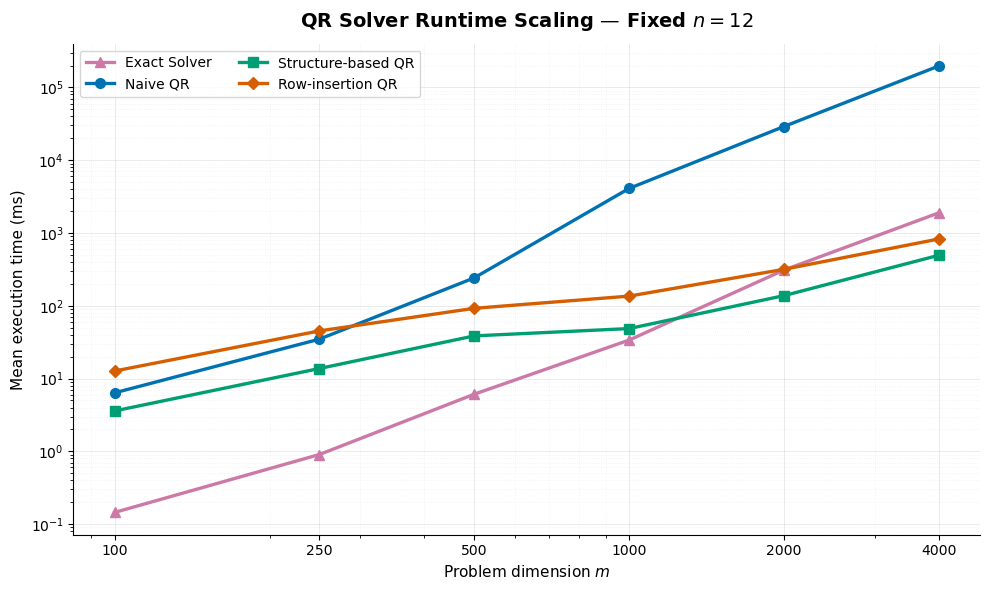

In [35]:
# Convert times from seconds to milliseconds
m_values = np.asarray(m_scaling_sizes, dtype=float)
exact_times_ms = 1e3 * np.asarray(mean_exact_times)
naive_times_ms = 1e3 * np.asarray(mean_naive_times)
struct_times_ms = 1e3 * np.asarray(mean_struct_times)
row_times_ms = 1e3 * np.asarray(mean_row_times)

# Reference slopes, anchored to the final corresponding measurement
cubic_guide_ms = (naive_times_ms[-1] * (m_values / m_values[-1]) ** 3)
quadratic_guide_ms = (struct_times_ms[-1] * (m_values / m_values[-1]) ** 2)

fig, ax = plt.subplots(figsize=(10, 6))

# Measured execution times
ax.plot(
    m_values,
    exact_times_ms,
    marker="^",
    markersize=7,
    linewidth=2.4,
    color="#CC79A7",
    label="Exact Solver"
)
ax.plot(
    m_values,
    naive_times_ms,
    marker="o",
    markersize=7,
    linewidth=2.4,
    color="#0072B2",
    label="Naive QR",
)
ax.plot(
    m_values,
    struct_times_ms,
    marker="s",
    markersize=7,
    linewidth=2.4,
    color="#009E73",
    label="Structure-based QR",
)
ax.plot(
    m_values,
    row_times_ms,
    marker="D",
    markersize=6,
    linewidth=2.4,
    color="#D55E00",
    label="Row-insertion QR",
)

# Logarithmic scales
ax.set_xscale("log")
ax.set_yscale("log")

# Display all sampled values on the x-axis
ax.set_xticks(m_values)
ax.set_xticklabels([str(int(m_size)) for m_size in m_values])
ax.set_xlabel("Problem dimension $m$", fontsize=11)
ax.set_ylabel("Mean execution time (ms)", fontsize=11)
ax.set_title(f"QR Solver Runtime Scaling — Fixed $n={X.shape[1]}$", fontsize=14, fontweight="semibold", pad=12)

# Improve readability
ax.grid(
    True,
    which="major",
    linestyle="-",
    linewidth=0.7,
    alpha=0.25,
)
ax.grid(
    True,
    which="minor",
    linestyle=":",
    linewidth=0.6,
    alpha=0.18,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=True, fontsize=10, ncol=2, loc="best")
fig.tight_layout()
plt.show()

### Interpretation of the timing experiment

- The valid structure-based implementation removes the cubic term of generic dense QR for fixed $n$ and is already faster on the stored run.
- Generic dense QR performs large vectorized array operations; constants and optimized low-level kernels can therefore matter greatly before asymptotic growth dominates.
- The normal-equations curve has a favorable partial timer, so it must not be read as a complete solver comparison; it also trades numerical robustness for speed.
- Row insertion contains the factorization defect described above. Its timings characterize the current Python loops and allocation pattern, but not the runtime of a verified solver.
- Five averaged measurements are useful empirical observations, not a proof of asymptotic complexity. No reference-slope curves are visible in the current plot.

## Numerical Stability as $\lambda$ Varies

The intended sweep compares each computed solution with an independent thin-SVD reference. If $X=U\Sigma V^T$, the spectral Tikhonov solution is

$$
w_{\mathrm{SVD}}=U\,\operatorname{diag}\!\left(\frac{\sigma_i}{\sigma_i^2+\lambda^2}\right)V^Ty.
$$

For each method, the relative forward error is

$$
e_{\mathrm{fwd}}=\frac{\|w-w_{\mathrm{SVD}}\|_2}{\|w_{\mathrm{SVD}}\|_2},
$$

while the scaled first-order residual is

$$
\eta_{\mathrm{opt}}=\frac{\|\hat X^T(\hat Xw-\hat y)\|_2}{\|\hat X\|_2\,\|\hat Xw-\hat y\|_2}.
$$

At a least-squares solution, the residual is orthogonal to the columns of $\hat X$, so a small $\eta_{\mathrm{opt}}$ indicates accurate satisfaction of the optimality condition. For this dataset $m>n$; consequently $X^T$ has a null space and

$$
\kappa_2(\hat X)=\frac{\sqrt{\sigma_{\max}(X)^2+\lambda^2}}{\lambda},
$$

which grows approximately as $1/\lambda$ when $\lambda$ is small. The SVD is used only for diagnosis and is not part of any QR solver. The validity limitations of the current sweep are stated after the tables and plots.

In [36]:
# Lambda values
stability_lambdas = np.logspace(-12, 4, 17)

# Machine values
machine_epsilon = np.finfo(float).eps
tiny = np.finfo(float).tiny

# Compute an independent SVD reference once for all lambda values
U_X, singular_values_X, Vt_X = np.linalg.svd(X, full_matrices=False)
spectral_coordinates = Vt_X @ y
sigma_max_X = singular_values_X[0]

condition_numbers = []
exact_relative_errors = []
naive_relative_errors = []
struct_relative_errors = []
row_relative_errors = []
exact_scaled_optimalities = []
naive_scaled_optimalities = []
struct_scaled_optimalities = []
row_scaled_optimalities = []

for lam in stability_lambdas:
    spectral_filter = singular_values_X / (singular_values_X ** 2 + lam ** 2)
    w_svd = U_X @ (spectral_filter * spectral_coordinates)

    augmented_matrix_norm = np.hypot(sigma_max_X, lam)
    smallest_augmented_singular_value = lam if X.shape[0] > singular_values_X.size else np.hypot(singular_values_X[-1], lam)
    condition_number = augmented_matrix_norm / smallest_augmented_singular_value

    condition_numbers.append(condition_number)

    _, w_naive, _, _, _  = naive_qr_solver(X, y, lam)
    _, w_struct, _, _, _ = qr_solver_structure_based(X, y, lam)
    _, w_row, _, _, _    = qr_solver_row_insertion(X, y, lam)

    # The normal-equations matrix can become numerically singular for tiny lambda.
    try:
        w_exact, _, _ = utils.solve_exact(X, y, lam)
    except np.linalg.LinAlgError:
        w_exact = np.full_like(w_svd, np.nan)


    exact_relative_error = utils.relative_error(w_exact, w_svd)
    naive_relative_error = utils.relative_error(w_naive, w_svd)
    struct_relative_error = utils.relative_error(w_struct, w_svd)
    row_relative_error = utils.relative_error(w_row, w_svd)

    exact_scaled_optimality = utils.compute_scaled_optimality(w_exact, X, y, lam, sigma_max_X)
    naive_scaled_optimality = utils.compute_scaled_optimality(w_naive, X, y, lam, sigma_max_X)
    struct_scaled_optimality = utils.compute_scaled_optimality(w_struct, X, y, lam, sigma_max_X)
    row_scaled_optimality = utils.compute_scaled_optimality(w_row, X, y, lam, sigma_max_X)

    exact_relative_errors.append(exact_relative_error)
    naive_relative_errors.append(naive_relative_error)
    struct_relative_errors.append(struct_relative_error)
    row_relative_errors.append(row_relative_error)

    exact_scaled_optimalities.append(exact_scaled_optimality)
    naive_scaled_optimalities.append(naive_scaled_optimality)
    struct_scaled_optimalities.append(struct_scaled_optimality)
    row_scaled_optimalities.append(row_scaled_optimality)


In [37]:
print("Numerical Stability — Relative Forward Errors:\n")
print('-' * 110)
print(f'{"lambda":>10} {"kappa(X_hat)":>16} {"Exact Solver":>18} {"Naive QR":>18} {"Structure-Based QR":>20} {"Row Insertion QR":>18}')
print('-' * 110)
for index, lam in enumerate(stability_lambdas):
    print(f'{lam:>10.0e} {condition_number:>16.3e} {exact_relative_error:>18.3e} {naive_relative_error:>18.3e} {struct_relative_error:>20.3e} {row_relative_error:>18.3e}')


Numerical Stability — Relative Forward Errors:

--------------------------------------------------------------------------------------------------------------
    lambda     kappa(X_hat)       Exact Solver           Naive QR   Structure-Based QR   Row Insertion QR
--------------------------------------------------------------------------------------------------------------
     1e-12        1.000e+00          2.564e-15          3.892e-13            2.936e-15          1.000e+00
     1e-11        1.000e+00          2.564e-15          3.892e-13            2.936e-15          1.000e+00
     1e-10        1.000e+00          2.564e-15          3.892e-13            2.936e-15          1.000e+00
     1e-09        1.000e+00          2.564e-15          3.892e-13            2.936e-15          1.000e+00
     1e-08        1.000e+00          2.564e-15          3.892e-13            2.936e-15          1.000e+00
     1e-07        1.000e+00          2.564e-15          3.892e-13            2.936e-15        

In [38]:

print("\nNumerical Stability — Scaled Optimality Residuals:\n")
print('-' * 110)
print(f'{"lambda":>10} {"kappa(X_hat)":>16} {"Exact Solver":>18} {"Naive QR":>18} {"Structure-Based QR":>20} {"Row Insertion QR":>18}')
print('-' * 110)
for index, lam in enumerate(stability_lambdas):
    print(f'{lam:>10.0e} {condition_numbers[index]:>16.3e} {exact_scaled_optimalities[index]:>18.3e} {naive_scaled_optimalities[index]:>18.3e} {struct_scaled_optimalities[index]:>20.3e} {row_scaled_optimalities[index]:>18.3e}')


Numerical Stability — Scaled Optimality Residuals:

--------------------------------------------------------------------------------------------------------------
    lambda     kappa(X_hat)       Exact Solver           Naive QR   Structure-Based QR   Row Insertion QR
--------------------------------------------------------------------------------------------------------------
     1e-12        7.575e+13          1.923e-03          2.013e-03            6.644e-05          7.566e-01
     1e-11        7.575e+12          1.923e-04          5.562e-05            1.082e-04          7.566e-01
     1e-10        7.575e+11          1.923e-05          2.210e-05            3.215e-06          7.566e-01
     1e-09        7.575e+10          1.923e-06          1.514e-06            3.658e-07          7.567e-01
     1e-08        7.575e+09          8.278e-08          5.858e-08            7.333e-08          7.569e-01
     1e-07        7.575e+08          5.172e-09          1.502e-08            7.379e-09   

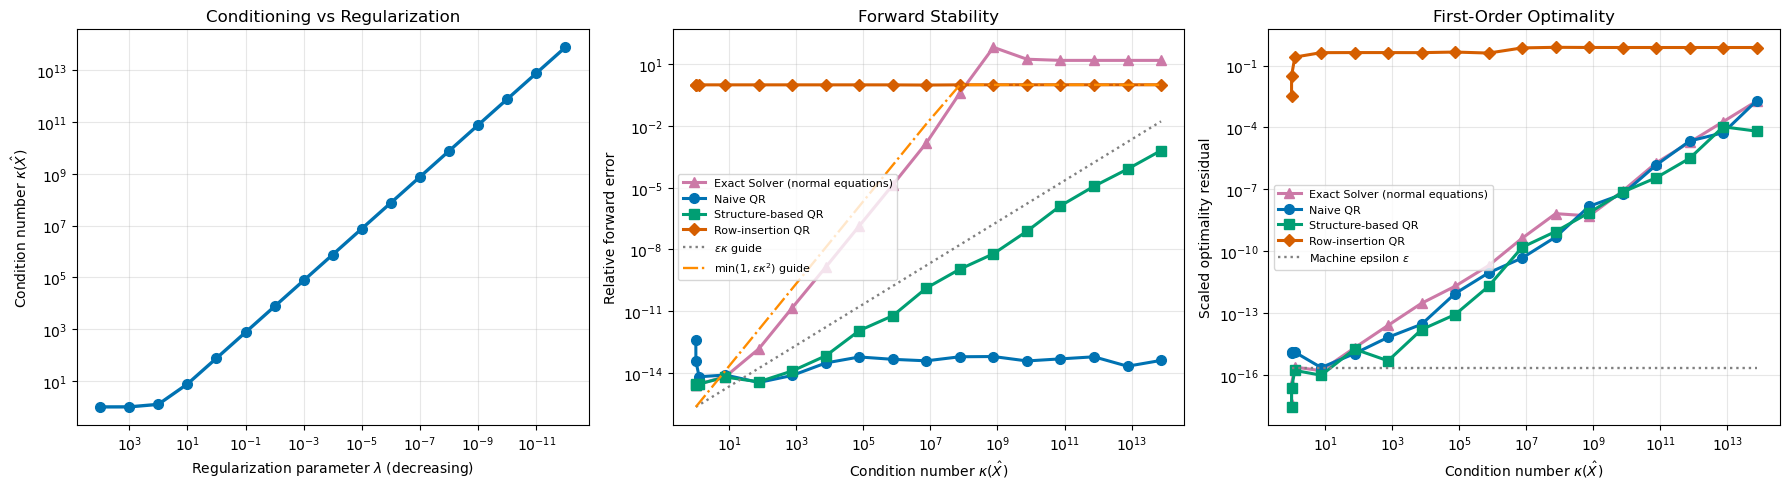

In [39]:
stability_lambdas_plot = np.asarray(stability_lambdas)
condition_numbers_plot = np.asarray(condition_numbers)
exact_relative_errors_plot = np.maximum(np.asarray(exact_relative_errors), tiny)
naive_relative_errors_plot = np.maximum(np.asarray(naive_relative_errors), tiny)
struct_relative_errors_plot = np.maximum(np.asarray(struct_relative_errors), tiny)
row_relative_errors_plot = np.maximum(np.asarray(row_relative_errors), tiny)
exact_scaled_optimalities_plot = np.maximum(np.asarray(exact_scaled_optimalities), tiny)
naive_scaled_optimalities_plot = np.maximum(np.asarray(naive_scaled_optimalities), tiny)
struct_scaled_optimalities_plot = np.maximum(np.asarray(struct_scaled_optimalities), tiny)
row_scaled_optimalities_plot = np.maximum(np.asarray(row_scaled_optimalities), tiny)

# Sort by condition number to make the stability trends explicit.
sorted_indices = np.argsort(condition_numbers_plot)
condition_numbers_sorted = condition_numbers_plot[sorted_indices]
epsilon_kappa_guide = machine_epsilon * condition_numbers_sorted
epsilon_kappa_squared_guide = np.minimum(1.0, machine_epsilon * condition_numbers_sorted ** 2)
machine_epsilon_guide = np.full_like(condition_numbers_sorted, machine_epsilon)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Smaller lambda moves to the right, matching increasing ill-conditioning.
axes[0].loglog(stability_lambdas_plot, condition_numbers_plot, marker='o', linewidth=2.4, markersize=7, color='#0072B2')
axes[0].invert_xaxis()
axes[0].set(
    xlabel=r'Regularization parameter $\lambda$ (decreasing)',
    ylabel=r'Condition number $\kappa(\hat X)$',
    title='Conditioning vs Regularization',
)

# Compare the relative forward errors of all solvers.
axes[1].loglog(
    condition_numbers_sorted,
    exact_relative_errors_plot[sorted_indices],
    marker='^', linewidth=2.2, markersize=7, color='#CC79A7',
    label='Exact Solver (normal equations)',
)
axes[1].loglog(
    condition_numbers_sorted,
    naive_relative_errors_plot[sorted_indices],
    marker='o', linewidth=2.2, markersize=7, color='#0072B2',
    label='Naive QR',
)
axes[1].loglog(
    condition_numbers_sorted,
    struct_relative_errors_plot[sorted_indices],
    marker='s', linewidth=2.2, markersize=7, color='#009E73',
    label='Structure-based QR',
)
axes[1].loglog(
    condition_numbers_sorted,
    row_relative_errors_plot[sorted_indices],
    marker='D', linewidth=2.2, markersize=6, color='#D55E00',
    label='Row-insertion QR',
)
axes[1].loglog(condition_numbers_sorted, epsilon_kappa_guide, ':', linewidth=1.7, color='gray', label=r'$\varepsilon\kappa$ guide')
axes[1].loglog(condition_numbers_sorted, epsilon_kappa_squared_guide, '-.', linewidth=1.7, color='darkorange', label=r'$\min(1,\varepsilon\kappa^2)$ guide')
axes[1].set(
    xlabel=r'Condition number $\kappa(\hat X)$',
    ylabel='Relative forward error',
    title='Forward Stability',
)
axes[1].legend(fontsize=8)

# Compare the scaled first-order optimality residuals of all solvers.
axes[2].loglog(
    condition_numbers_sorted,
    exact_scaled_optimalities_plot[sorted_indices],
    marker='^', linewidth=2.2, markersize=7, color='#CC79A7',
    label='Exact Solver (normal equations)',
)
axes[2].loglog(
    condition_numbers_sorted,
    naive_scaled_optimalities_plot[sorted_indices],
    marker='o', linewidth=2.2, markersize=7, color='#0072B2',
    label='Naive QR',
)
axes[2].loglog(
    condition_numbers_sorted,
    struct_scaled_optimalities_plot[sorted_indices],
    marker='s', linewidth=2.2, markersize=7, color='#009E73',
    label='Structure-based QR',
)
axes[2].loglog(
    condition_numbers_sorted,
    row_scaled_optimalities_plot[sorted_indices],
    marker='D', linewidth=2.2, markersize=6, color='#D55E00',
    label='Row-insertion QR',
)
axes[2].loglog(condition_numbers_sorted, machine_epsilon_guide, ':', linewidth=1.7, color='gray', label=r'Machine epsilon $\varepsilon$')
axes[2].set(
    xlabel=r'Condition number $\kappa(\hat X)$',
    ylabel='Scaled optimality residual',
    title='First-Order Optimality',
)
axes[2].legend(fontsize=8)

for axis in axes:
    axis.grid(alpha=0.3, which='both')

fig.tight_layout()
plt.show()

### Interpretation and validity of the current stability run

The condition-number computation, SVD reference, normal-equations calls, and structure-based calls all use the current value of $\lambda$. Their stored arrays and plotted curves can therefore be compared as functions of conditioning. Householder QR is expected to behave on an $O(\varepsilon\kappa)$ forward-error scale, whereas forming normal equations can introduce an $O(\varepsilon\kappa^2)$ scale. The plotted guide curves illustrate these tendencies; they are not strict error bounds.

Three implementation details prevent a valid four-solver conclusion from the notebook in its current form:

1. `A` and `b` are built once in the dense-QR section with $\lambda=0.5$. Inside the sweep, `naive_qr_solver(A, b)` reuses that fixed problem instead of rebuilding it for the current $\lambda$, so the naive-QR stability series does not represent the requested sweep.
2. The row-insertion series inherits the factorization defect documented above and is not a valid QR stability measurement.
3. The printed *Relative Forward Errors* table uses the final scalar variables inside every row instead of indexing the stored arrays. It therefore repeats the final iteration's values. The plots do use the arrays, but their naive and row-insertion curves remain invalid for reasons 1 and 2.

Accordingly, the current experiment supports interpretation of the conditioning, normal-equations, and structure-based data only. A solver should be declared stable only after it both agrees with the SVD reference and has a small scaled optimality residual.

## Summary

- Generic dense Householder QR correctly factorizes the explicit augmented matrix without forming $Q$, but ignores its structure and costs $O(m^3+nm^2)$.
- Structure-based QR exploits $\lambda I_m$, stores $m$ reflectors of length $n+1$, and costs $O(nm^2+m^2)$; the leading transformed right-hand side used by its solve is correct.
- Two-dimensional row insertion is designed to have the same quadratic order for fixed $n$, but the current update order overwrites its elimination values. Its saved accuracy and stability results are therefore not valid solver results.
- The module applies $Q^T$ implicitly where required; no public reverse scan for applying $Q$ is implemented or tested here.
- The normal-equations routine is a convenient but partially timed and conditioning-sensitive baseline. The SVD experiment is the independent accuracy reference.
- Runtime and stability conclusions must respect the timer-scope and sweep limitations documented above.